In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [32]:
def load_my_data():
    url = "spam.csv"
    df = pd.read_csv(url)
    return df

df = load_my_data()
print("Shape:", df.shape)
df.head()

Shape: (201, 8)


,num_links,num_exclamations,num_caps_words,email_length,has_attachment,sender_known,contains_offer,label
0,3,5,4,120,0,0,1,1
1,0,0,0,45,1,1,0,0
2,2,3,2,90,0,0,1,1
3,0,0,0,30,0,1,0,0
4,4,6,5,150,0,0,1,1


In [33]:
df.describe()

,num_links,num_exclamations,num_caps_words,email_length,has_attachment,sender_known,contains_offer,label
count,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,1.781095,2.308458,1.616915,90.074627,0.258706,0.522388,0.477612,0.477612
std,1.578557,2.189607,1.920290,48.410427,0.439017,0.500746,0.500746,0.500746
min,0.000000,0.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,46.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,2.000000,1.000000,85.000000,0.000000,1.000000,0.000000,0.000000
75%,3.000000,4.000000,3.000000,130.000000,1.000000,1.000000,1.000000,1.000000
max,5.000000,7.000000,6.000000,190.000000,1.000000,1.000000,1.000000,1.000000


In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   num_links         201 non-null    int64
 1   num_exclamations  201 non-null    int64
 2   num_caps_words    201 non-null    int64
 3   email_length      201 non-null    int64
 4   has_attachment    201 non-null    int64
 5   sender_known      201 non-null    int64
 6   contains_offer    201 non-null    int64
 7   label             201 non-null    int64
dtypes: int64(8)
memory usage: 12.7 KB


In [35]:
df.isnull().sum()

num_links           0
num_exclamations    0
num_caps_words      0
email_length        0
has_attachment      0
sender_known        0
contains_offer      0
label               0
dtype: int64

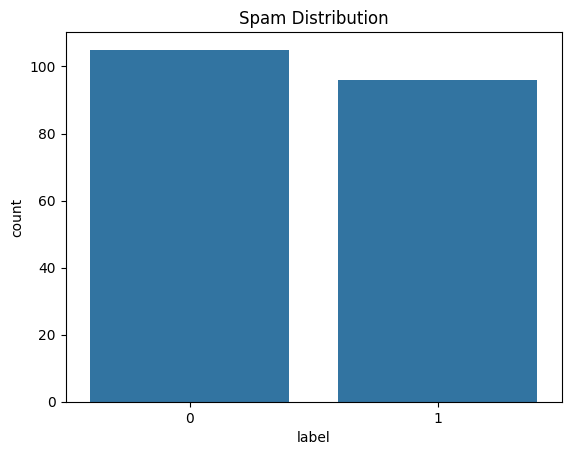

In [36]:
sns.countplot(x='label', data=df)
plt.title('Spam Distribution')
plt.show()

In [37]:
def split_data(df):
    X = df.drop('label', axis=1)
    y = df["label"]
    return train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)
X_train, X_test, y_train, y_test = split_data(df)

In [38]:
def train_random_forest(X_train,y_train,X_test,y_test):
    rf = RandomForestClassifier(n_estimators=89,max_depth=5,random_state=42)
    rf.fit(X_train,y_train)
    preds = rf.predict(X_test)
    acc=accuracy_score(y_test,preds)
    return acc, preds
rf_acc, rf_preds = train_random_forest(X_train,y_train,X_test,y_test)
print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 1.0


In [39]:
rf_preds

array([0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1])

In [40]:
from sklearn.utils import resample
from scipy.stats import mode
def bagger_fit_predict(model_fns, X_train, y_train,X_test, n_estimators= 10):
    all_preds = []
    for fn in model_fns:
        for i in range(n_estimators):
            X_bs, y_bs = resample(X_train,y_train, replace=True)
            model = fn()
            model.fit(X_bs,y_bs)
            preds = model.predict(X_test)
            all_preds.append(preds)
    all_preds = np.array(all_preds)
    final_preds = mode(all_preds,axis=0).mode
    return final_preds.ravel()

model_list = [
    lambda: DecisionTreeClassifier(max_depth=5),
    lambda: KNeighborsClassifier(n_neighbors=5),
    lambda: LogisticRegression(max_iter=7000)
]

bagger_preds = bagger_fit_predict(
    model_fns=model_list,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    n_estimators=15
)
bagger_acc = accuracy_score(y_test, bagger_preds)
print("Custom Bagger Accuracy:", bagger_acc)
    

Custom Bagger Accuracy: 0.975609756097561


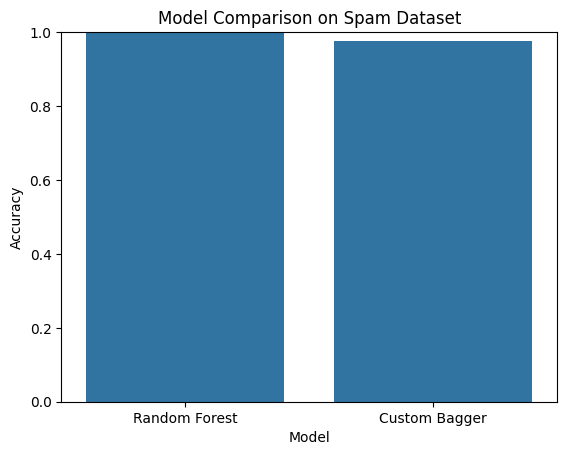

,Model,Accuracy
0,Random Forest,1.00000
1,Custom Bagger,0.97561


In [43]:
results = pd.DataFrame({
    "Model": ["Random Forest", "Custom Bagger"],
    "Accuracy": [rf_acc, bagger_acc]
})

sns.barplot(x="Model", y="Accuracy", data=results)
plt.title("Model Comparison on Spam Dataset")
plt.ylim(0, 1)
plt.show()

results

In [47]:
print("Classification Report (Custom Bagger):")
print(classification_report(y_test, bagger_preds))
print(accuracy_score(y_test, bagger_preds))
print(confusion_matrix(y_test, bagger_preds))




Classification Report (Custom Bagger):
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        21
           1       0.95      1.00      0.98        20

    accuracy                           0.98        41
   macro avg       0.98      0.98      0.98        41
weighted avg       0.98      0.98      0.98        41

0.975609756097561
[[20  1]
 [ 0 20]]


In [46]:
print("Classification Report (Random Forest):")
print(classification_report(y_test, rf_preds))
print(accuracy_score(y_test, rf_preds))
print(confusion_matrix(y_test, rf_preds))

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        20

    accuracy                           1.00        41
   macro avg       1.00      1.00      1.00        41
weighted avg       1.00      1.00      1.00        41

1.0
[[21  0]
 [ 0 20]]
